,time,orientation,distance,velocity,fitness,x_robot0,y_robot0,x_robot1,y_robot1,x_robot2,y_robot2,x_robot3,y_robot3,x_robot4,y_robot4
0,0,0.999853,0.909490,0.292316,0.265820,-1.387419,1.849998,-1.389251,1.550405,-1.387806,1.700003,-1.394419,1.400000,-1.394267,2.000000
1,320,0.944817,0.911445,0.121476,0.104609,-1.356886,1.850084,-1.358667,1.551761,-1.357718,1.700081,-1.399364,1.399819,-1.398335,2.000198
2,640,0.687398,0.912312,0.116392,0.072992,-1.326389,1.850301,-1.328109,1.553246,-1.327197,1.700202,-1.397652,1.397411,-1.396367,2.002424
3,960,0.401980,0.912780,0.108014,0.039632,-1.295840,1.850553,-1.297744,1.554810,-1.296579,1.700362,-1.399160,1.392932,-1.396826,2.006029
4,1280,0.284767,0.913374,0.104132,0.027085,-1.265355,1.850766,-1.267187,1.556412,-1.266059,1.700709,-1.403365,1.389046,-1.400158,2.010325


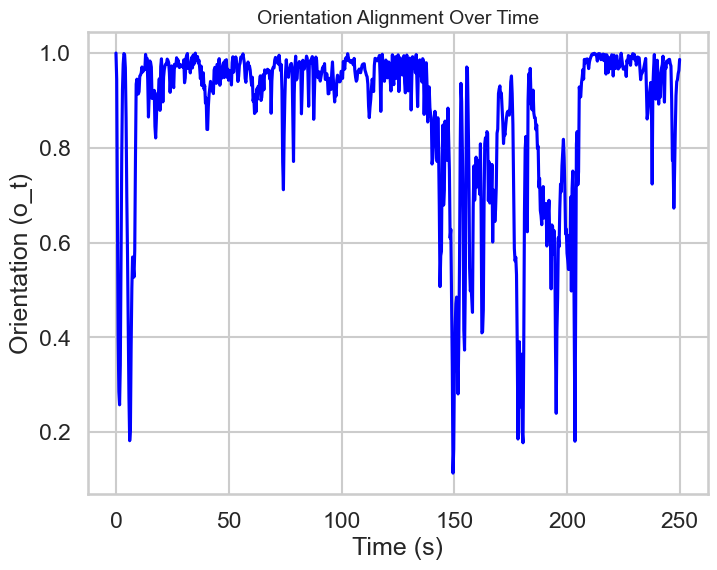

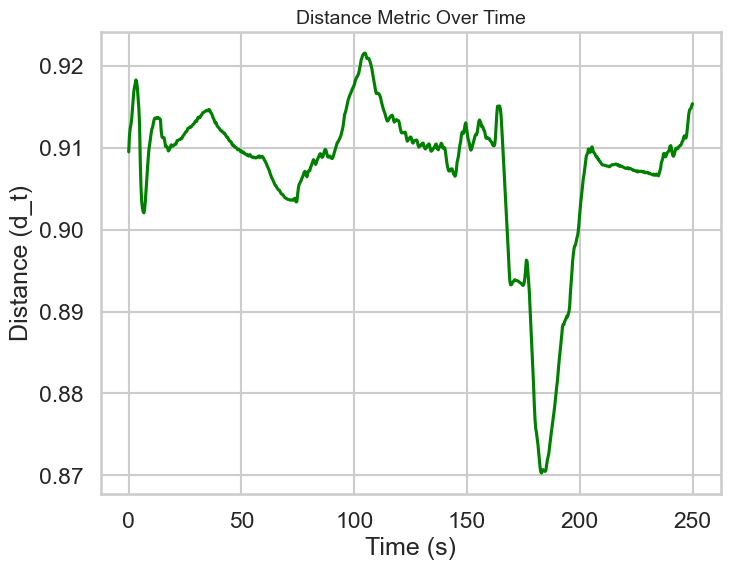

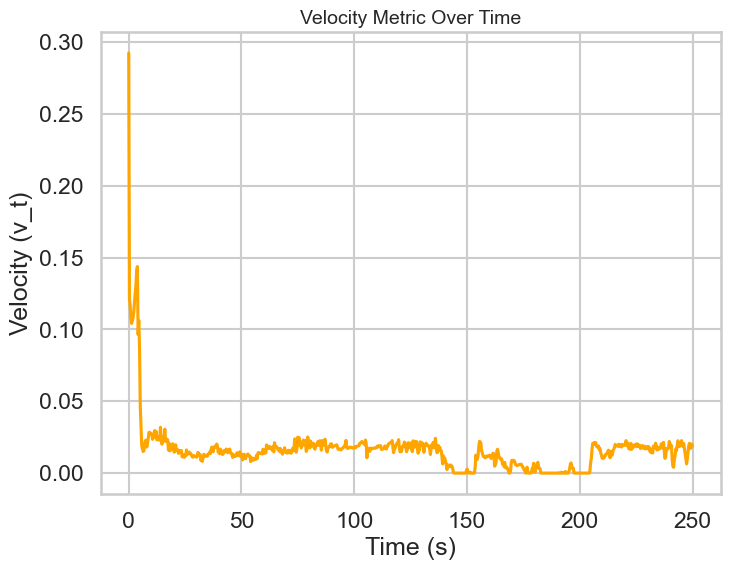

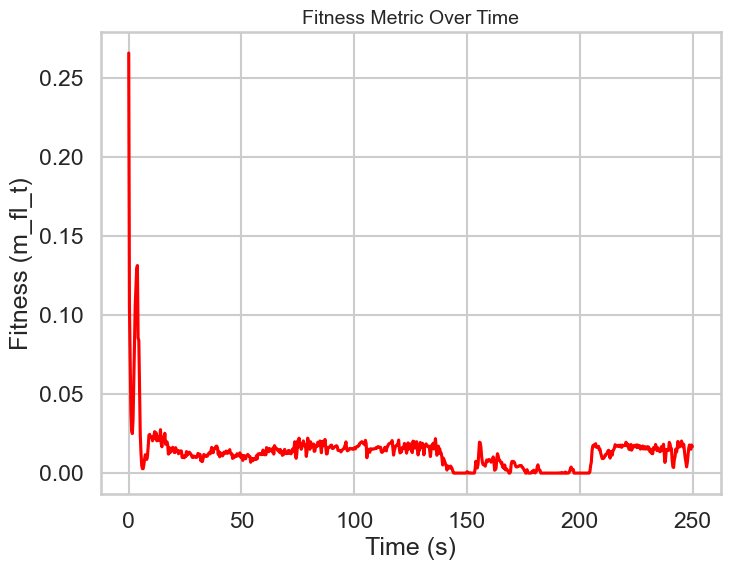

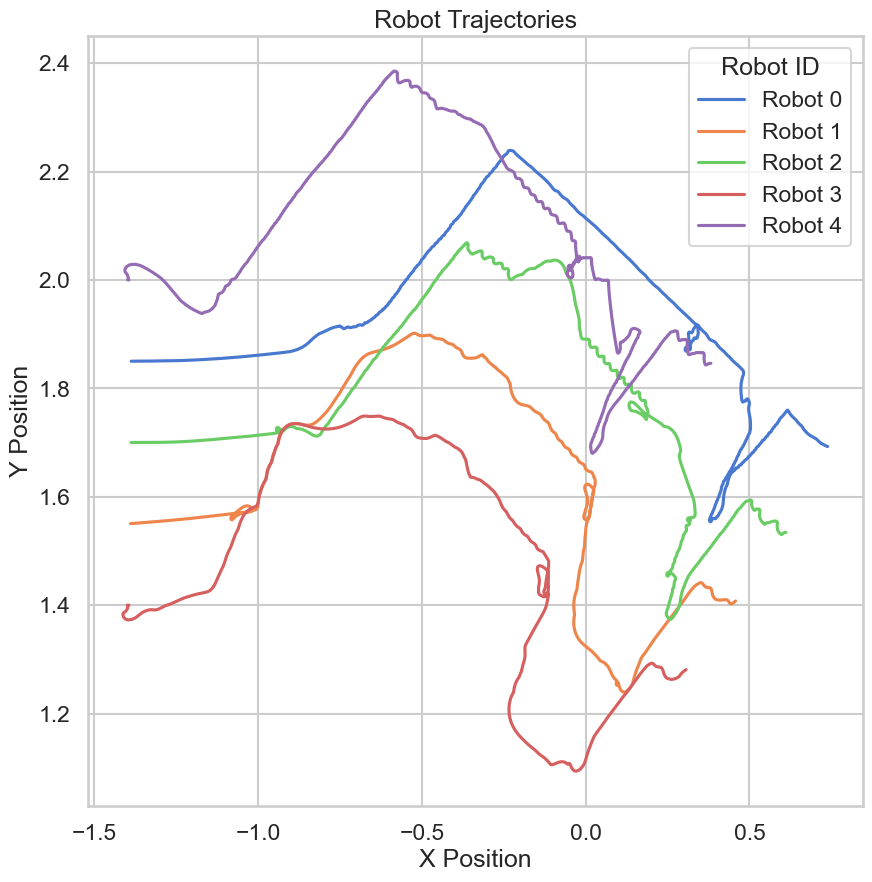

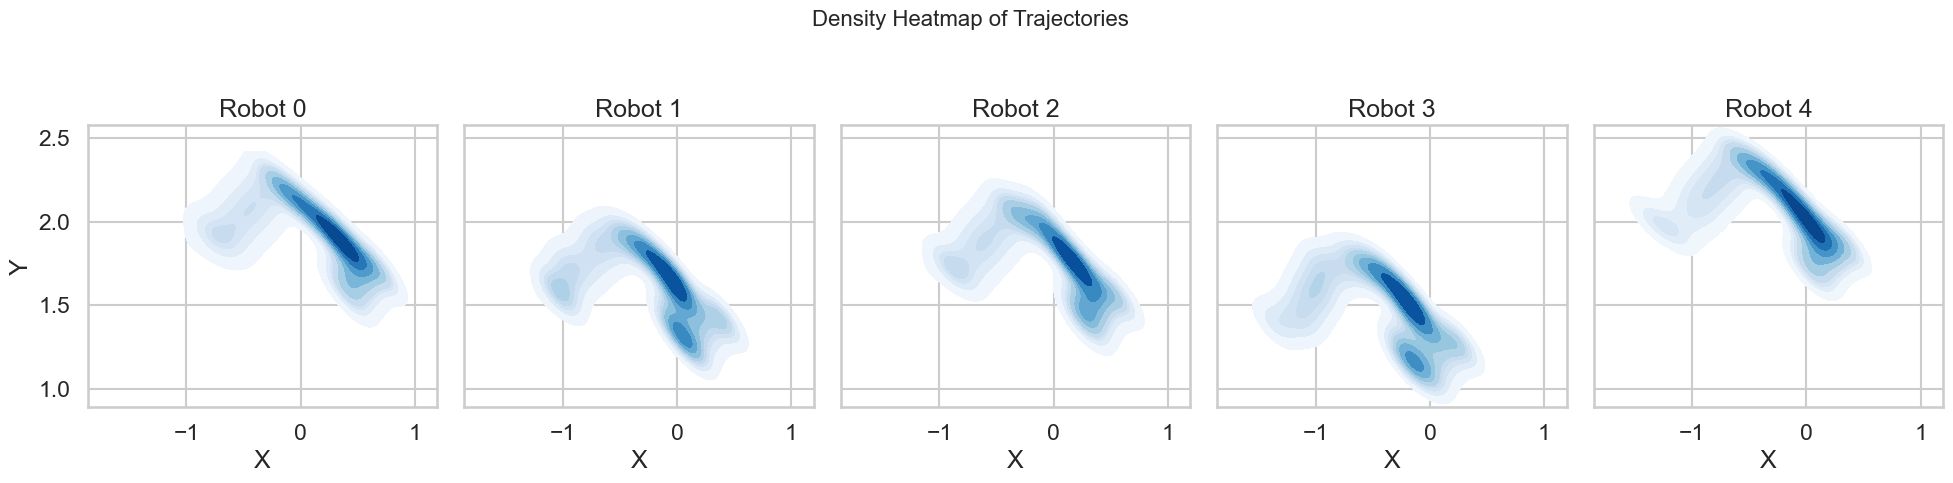

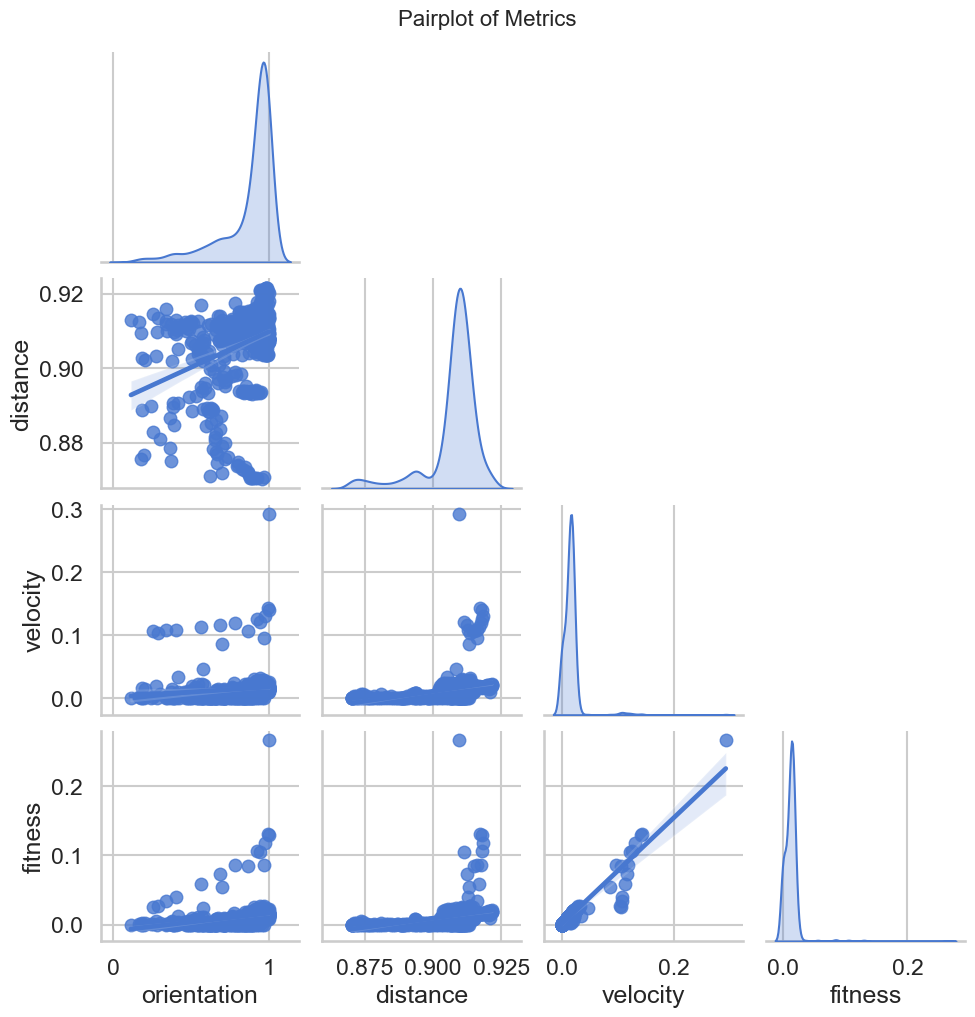

In [22]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV file
# Replace 'flock_data.csv' with the actual name of the generated CSV file
csv_file = "controllers/super/flocking_data.csv"
data = pd.read_csv(csv_file)

# Rename columns for better understanding
data.columns = ["time", "orientation", "distance", "velocity", "fitness"] + \
               ["x_robot0", "y_robot0", "x_robot1", "y_robot1", "x_robot2", "y_robot2"] + \
               ["x_robot3", "y_robot3", "x_robot4", "y_robot4"]

# Preview the data
display(data.head())

# Ensure time is in seconds for clarity
data['time'] = data['time'] / 1000  # Assuming time was logged in milliseconds

# Configure global style for professional plots
sns.set(style="whitegrid", palette="muted", context="talk")

# Separate plot for Orientation Metric
def plot_orientation(data):
    plt.figure(figsize=(8, 6))
    sns.lineplot(x="time", y="orientation", data=data, color="blue")
    plt.title("Orientation Alignment Over Time", fontsize=14)
    plt.xlabel("Time (s)")
    plt.ylabel("Orientation (o_t)")
    plt.grid(True)
    plt.show()

# Separate plot for Distance Metric
def plot_distance(data):
    plt.figure(figsize=(8, 6))
    sns.lineplot(x="time", y="distance", data=data, color="green")
    plt.title("Distance Metric Over Time", fontsize=14)
    plt.xlabel("Time (s)")
    plt.ylabel("Distance (d_t)")
    plt.grid(True)
    plt.show()

# Separate plot for Velocity Metric
def plot_velocity(data):
    plt.figure(figsize=(8, 6))
    sns.lineplot(x="time", y="velocity", data=data, color="orange")
    plt.title("Velocity Metric Over Time", fontsize=14)
    plt.xlabel("Time (s)")
    plt.ylabel("Velocity (v_t)")
    plt.grid(True)
    plt.show()

# Separate plot for Fitness Metric
def plot_fitness(data):
    plt.figure(figsize=(8, 6))
    sns.lineplot(x="time", y="fitness", data=data, color="red")
    plt.title("Fitness Metric Over Time", fontsize=14)
    plt.xlabel("Time (s)")
    plt.ylabel("Fitness (m_fl_t)")
    plt.grid(True)
    plt.show()

# Call individual plotting functions
plot_orientation(data)
plot_distance(data)
plot_velocity(data)
plot_fitness(data)

# Plot trajectories for all robots
def plot_trajectories(data):
    fig, ax = plt.subplots(figsize=(10, 10))

    # Use plt.plot for each robot's trajectory
    for i in range(5):  # Iterate through the 5 robots
        ax.plot(
            data[f"x_robot{i}"], 
            data[f"y_robot{i}"], 
            label=f"Robot {i}"
        )

    ax.set_title("Robot Trajectories")
    ax.set_xlabel("X Position")
    ax.set_ylabel("Y Position")
    ax.legend(title="Robot ID")
    plt.grid(True)  # Add grid for better visualization
    plt.show()

# Call the updated function
plot_trajectories(data)

# Heatmap for trajectory density (optional)
def plot_density(data):
    fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharex=True, sharey=True)
    fig.suptitle("Density Heatmap of Trajectories", fontsize=16)

    for i in range(5):  # Iterate through the 5 robots
        sns.kdeplot(
            x=data[f"x_robot{i}"],
            y=data[f"y_robot{i}"],
            cmap="Blues",
            fill=True,
            ax=axes[i]
        )
        axes[i].set_title(f"Robot {i}")
        axes[i].set_xlabel("X")
        axes[i].set_ylabel("Y")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_density(data)

# Pairplot for all metrics (optional, detailed analysis)
def plot_pairplot(data):
    metrics = ["orientation", "distance", "velocity", "fitness"]
    sns.pairplot(data[metrics], diag_kind="kde", corner=True, kind="reg")
    plt.suptitle("Pairplot of Metrics", y=1.02, fontsize=16)
    plt.show()

plot_pairplot(data)



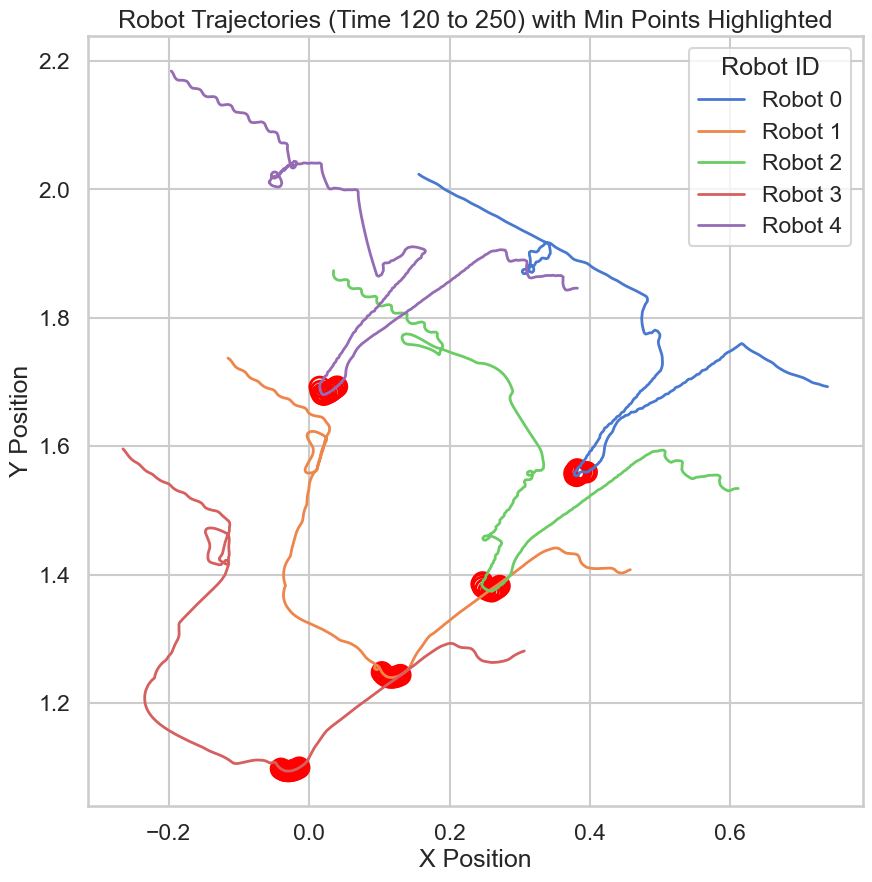

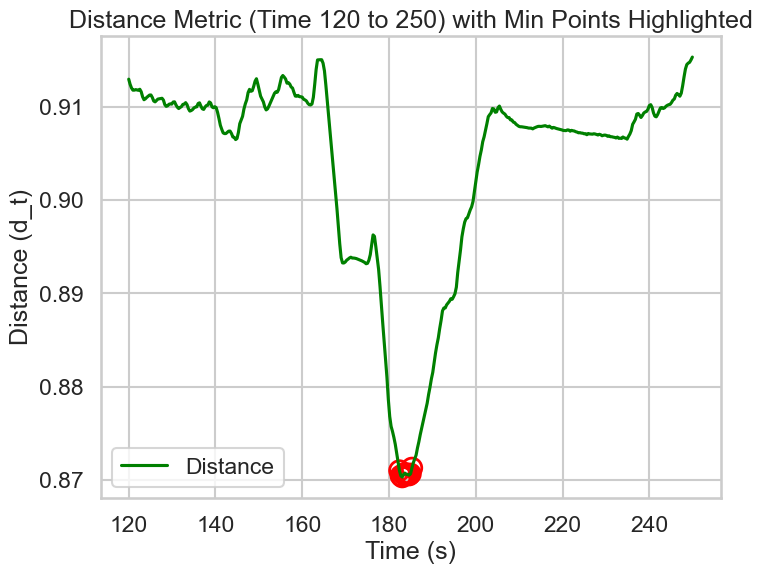

In [29]:
# Plot filtered trajectories with optional circles around minimum 10 points
def plot_filtered_trajectories_with_highlight(data, start_time, end_time, highlight_min_points=True):
    # Filter data for the specified time range
    filtered_data = data[(data["time"] >= start_time) & (data["time"] <= end_time)]

    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot trajectories for only the filtered range
    for i in range(5):  # Iterate through the 5 robots
        ax.plot(
            filtered_data[f"x_robot{i}"], 
            filtered_data[f"y_robot{i}"], 
            label=f"Robot {i}", 
            linewidth=2
        )

        # Highlight minimum 10 points if enabled
        if highlight_min_points:
            min_points_idx = filtered_data[[f"x_robot{i}", f"y_robot{i}"]].apply(
                lambda row: np.linalg.norm(row), axis=1
            ).nsmallest(10).index

            ax.scatter(
                filtered_data.loc[min_points_idx, f"x_robot{i}"], 
                filtered_data.loc[min_points_idx, f"y_robot{i}"], 
                edgecolor="red", 
                facecolor="none", 
                s=200, 
                linewidth=2
            )

    ax.set_title(f"Robot Trajectories (Time {start_time} to {end_time}) with Min Points Highlighted")
    ax.set_xlabel("X Position")
    ax.set_ylabel("Y Position")
    ax.legend(title="Robot ID", loc="best")
    plt.grid(True)
    plt.show()


# Plot filtered distance metric with optional circles around minimum 10 points
def plot_filtered_metrics_with_highlight(data, start_time, end_time, highlight_min_points=True):
    # Filter data for the specified time range
    filtered_data = data[(data["time"] >= start_time) & (data["time"] <= end_time)]

    # Distance Plot
    plt.figure(figsize=(8, 6))
    sns.lineplot(x="time", y="distance", data=filtered_data, color="green", label="Distance")

    # Highlight minimum 10 points if enabled
    if highlight_min_points:
        min_distance_idx = filtered_data["distance"].nsmallest(10).index
        plt.scatter(
            filtered_data.loc[min_distance_idx, "time"], 
            filtered_data.loc[min_distance_idx, "distance"], 
            edgecolor="red", 
            facecolor="none", 
            s=200, 
            linewidth=2
        )

    plt.title(f"Distance Metric (Time {start_time} to {end_time}) with Min Points Highlighted")
    plt.xlabel("Time (s)")
    plt.ylabel("Distance (d_t)")
    plt.legend()
    plt.grid(True)
    plt.show()

# Call the functions with the optional highlight_min_points parameter
plot_filtered_trajectories_with_highlight(data, start_time=120, end_time=250, highlight_min_points=True)
plot_filtered_metrics_with_highlight(data, start_time=120, end_time=250, highlight_min_points=True)


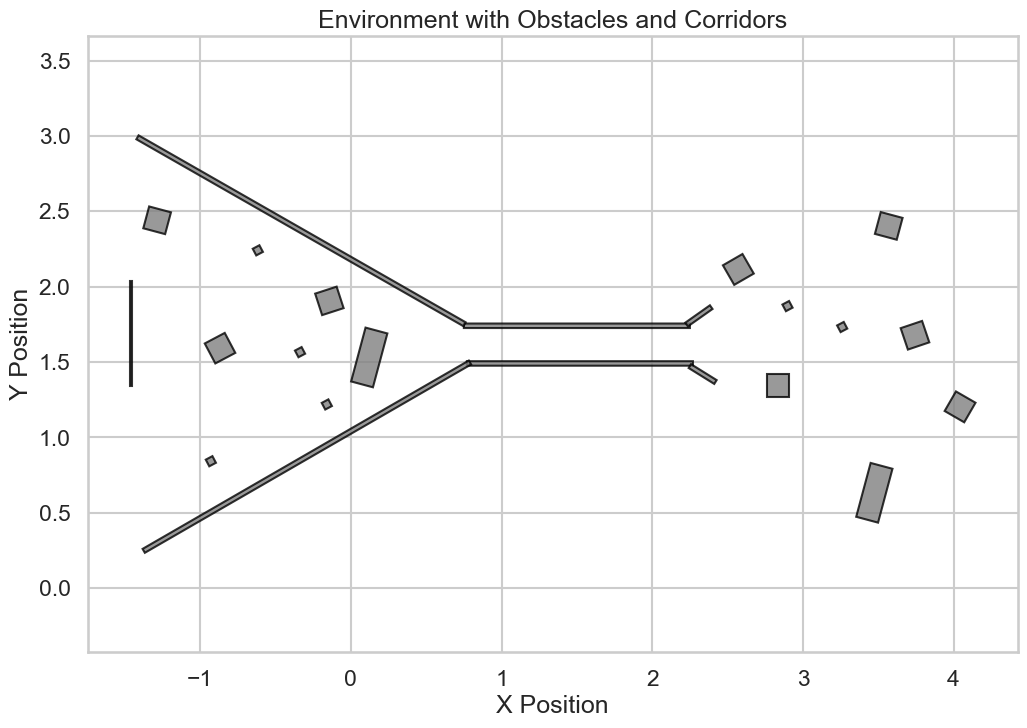

In [5]:
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np

# File path to the .wbt file
wbt_file = "worlds/topic3.wbt"

# Regex patterns to capture object names, translations, sizes, and rotations
object_pattern = re.compile(r"DEF (\w+) Solid {")
translation_pattern = re.compile(r"translation ([\d\-.]+) ([\d\-.]+) ([\d\-.]+)")
size_pattern = re.compile(r"size ([\d\-.]+) ([\d\-.]+) ([\d\-.]+)")
rotation_pattern = re.compile(r"rotation ([\d\-.]+) ([\d\-.]+) ([\d\-.]+) ([\d\-.]+)")

# Initialize lists to store obstacle data
obstacles = []

# Parse the .wbt file
with open(wbt_file, 'r') as file:
    lines = file.readlines()

# Extract object names, translations, sizes, and rotations
current_object = None
current_translation = None
current_rotation = None
current_size = None

for line in lines:
    object_match = object_pattern.search(line)
    if object_match:
        current_object = object_match.group(1)
        current_translation = None
        current_rotation = None
        current_size = None
        continue

    if current_object:
        translation_match = translation_pattern.search(line)
        if translation_match:
            current_translation = tuple(map(float, translation_match.groups()))

        rotation_match = rotation_pattern.search(line)
        if rotation_match:
            rotation_axis = tuple(map(float, rotation_match.groups()[:3]))
            current_rotation = float(rotation_match.group(4))  # Extract rotation angle in radians
            
            # Adjust the angle only for specific cases
            if current_object == "Corridor_3" and rotation_axis == (0.0, 0.0, -1.0):
                current_rotation -= 1.04281  # Subtract the specified value
            
            if current_object == "Corridor_2":
                current_rotation += 1.8

            if current_object == "Corridor_1":
                current_rotation += 1.4

        size_match = size_pattern.search(line)
        if size_match:
            current_size = tuple(map(float, size_match.groups()))

        # If all necessary data is gathered, append the obstacle
        if current_translation and current_size:
            rotation_angle = current_rotation if current_rotation is not None else 0
            obstacles.append({
                "name": current_object,
                "translation": current_translation,
                "size": current_size,
                "rotation": rotation_angle
            })
            current_object = None  # Reset for next object

# Remove migration target or irrelevant objects
obstacles = [obs for obs in obstacles if "migration_target" not in obs["name"]]

# Function to calculate rotated rectangle corners
def calculate_corners(center, size, rotation):
    cx, cy = center
    width, height = size[0], size[1]
    corners = [
        [-width / 2, -height / 2],
        [width / 2, -height / 2],
        [width / 2, height / 2],
        [-width / 2, height / 2],
    ]
    # Rotate corners
    rotated_corners = [
        [
            cx + corner[0] * np.cos(rotation) - corner[1] * np.sin(rotation),
            cy + corner[0] * np.sin(rotation) + corner[1] * np.cos(rotation),
        ]
        for corner in corners
    ]
    return rotated_corners

# Function to plot obstacles and corridors
def plot_obstacles(obstacles):
    fig, ax = plt.subplots(figsize=(12, 8))

    for obstacle in obstacles:
        x, y, z = obstacle["translation"]
        width, height, depth = obstacle["size"]
        rotation = obstacle["rotation"]

        # Calculate rotated rectangle corners
        corners = calculate_corners((x, y), (width, height), rotation)

        # Draw polygon for obstacle
        polygon = Polygon(corners, closed=True, edgecolor="black", facecolor="gray", alpha=0.8)
        ax.add_patch(polygon)

    ax.set_title("Environment with Obstacles and Corridors")
    ax.set_xlabel("X Position")
    ax.set_ylabel("Y Position")
    plt.grid(True)
    plt.axis("equal")
    plt.show()

# Call the function to plot
plot_obstacles(obstacles)


# Merged the Obstacle map with the trajectories

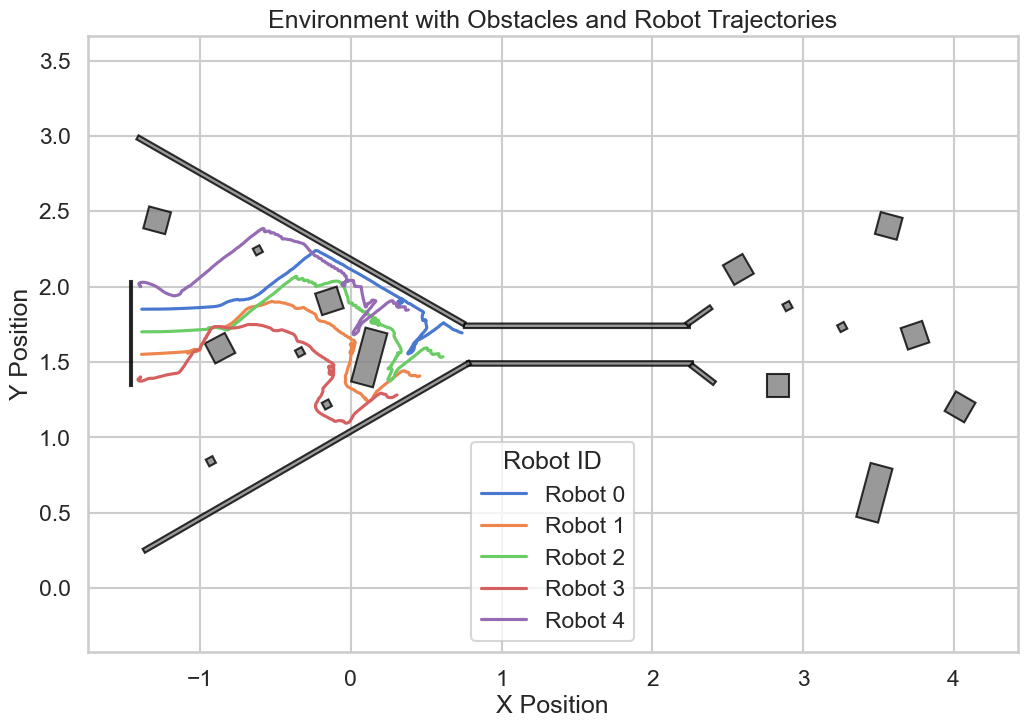

In [23]:
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import pandas as pd
import seaborn as sns

# File paths
wbt_file = "worlds/topic3.wbt"
csv_file = "controllers/super/flocking_data.csv"

# Load CSV file
data = pd.read_csv(csv_file)

# Rename columns for better understanding
data.columns = ["time", "orientation", "distance", "velocity", "fitness"] + \
               ["x_robot0", "y_robot0", "x_robot1", "y_robot1", "x_robot2", "y_robot2"] + \
               ["x_robot3", "y_robot3", "x_robot4", "y_robot4"]

# Ensure time is in seconds for clarity
data['time'] = data['time'] / 1000  # Assuming time was logged in milliseconds

# Regex patterns to capture object names, translations, sizes, and rotations
object_pattern = re.compile(r"DEF (\w+) Solid {")
translation_pattern = re.compile(r"translation ([\d\-.]+) ([\d\-.]+) ([\d\-.]+)")
size_pattern = re.compile(r"size ([\d\-.]+) ([\d\-.]+) ([\d\-.]+)")
rotation_pattern = re.compile(r"rotation ([\d\-.]+) ([\d\-.]+) ([\d\-.]+) ([\d\-.]+)")

# Initialize lists to store obstacle data
obstacles = []

# Parse the .wbt file
with open(wbt_file, 'r') as file:
    lines = file.readlines()

# Extract object names, translations, sizes, and rotations
current_object = None
current_translation = None
current_rotation = None
current_size = None

for line in lines:
    object_match = object_pattern.search(line)
    if object_match:
        current_object = object_match.group(1)
        current_translation = None
        current_rotation = None
        current_size = None
        continue

    if current_object:
        translation_match = translation_pattern.search(line)
        if translation_match:
            current_translation = tuple(map(float, translation_match.groups()))

        rotation_match = rotation_pattern.search(line)
        if rotation_match:
            rotation_axis = tuple(map(float, rotation_match.groups()[:3]))
            current_rotation = float(rotation_match.group(4))  # Extract rotation angle in radians
            
            # Adjust the angle only for specific cases
            if current_object == "Corridor_3" and rotation_axis == (0.0, 0.0, -1.0):
                current_rotation -= 1.04281  # Subtract the specified value
            
            if current_object == "Corridor_2":
                current_rotation += 1.7

            if current_object == "Corridor_1":
                current_rotation += 1.4

        size_match = size_pattern.search(line)
        if size_match:
            current_size = tuple(map(float, size_match.groups()))

        # If all necessary data is gathered, append the obstacle
        if current_translation and current_size:
            rotation_angle = current_rotation if current_rotation is not None else 0
            obstacles.append({
                "name": current_object,
                "translation": current_translation,
                "size": current_size,
                "rotation": rotation_angle
            })
            current_object = None  # Reset for next object

# Remove migration target or irrelevant objects
obstacles = [obs for obs in obstacles if "migration_target" not in obs["name"]]

# Function to calculate rotated rectangle corners
def calculate_corners(center, size, rotation):
    cx, cy = center
    width, height = size[0], size[1]
    corners = [
        [-width / 2, -height / 2],
        [width / 2, -height / 2],
        [width / 2, height / 2],
        [-width / 2, height / 2],
    ]
    # Rotate corners
    rotated_corners = [
        [
            cx + corner[0] * np.cos(rotation) - corner[1] * np.sin(rotation),
            cy + corner[0] * np.sin(rotation) + corner[1] * np.cos(rotation),
        ]
        for corner in corners
    ]
    return rotated_corners

# Function to plot obstacles and robot trajectories
def plot_environment_with_trajectories(obstacles, data):
    fig, ax = plt.subplots(figsize=(12, 8))

    # Plot obstacles
    for obstacle in obstacles:
        x, y, z = obstacle["translation"]
        width, height, depth = obstacle["size"]
        rotation = obstacle["rotation"]

        # Calculate rotated rectangle corners
        corners = calculate_corners((x, y), (width, height), rotation)

        # Draw polygon for obstacle
        polygon = Polygon(corners, closed=True, edgecolor="black", facecolor="gray", alpha=0.8)
        ax.add_patch(polygon)

    # Plot trajectories
    for i in range(5):  # Iterate through the 5 robots
        ax.plot(
            data[f"x_robot{i}"], 
            data[f"y_robot{i}"], 
            label=f"Robot {i}"
        )

    ax.set_title("Environment with Obstacles and Robot Trajectories")
    ax.set_xlabel("X Position")
    ax.set_ylabel("Y Position")
    ax.legend(title="Robot ID")
    plt.grid(True)  # Add grid for better visualization
    plt.axis("equal")  # Keep aspect ratio equal for better spatial representation
    plt.show()

# Call the function to plot
plot_environment_with_trajectories(obstacles, data)
